In [1]:
import nbimporter
from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision import transforms
from torch import nn
from torch.optim import SGD
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
from os.path import join
import torch
import numpy as np
from PIL import Image
from os import path

import python_file.dataclass as StreetSign
import python_file.function as Function
import python_file.network as Network

import matplotlib.pyplot as plt

from python_file.dirPath import csvDir, imageDir, Test, historiesDir, modelliDir, graphsDir

np.random.seed(1328)
torch.random.manual_seed(1328)

epoche        = 200 
learning_rate = 0.001
momento       = 0.6

exp_name_1='MiniAlexNetV2'
exp_name_2='MiniAlexNet'
exp_name_3='AlexNet'

csv_files = [historiesDir / f'{exp_name_1}_lr{learning_rate}_m{momento}-{epoche}.csv',
             historiesDir / f'{exp_name_2}_lr{learning_rate}_m{momento}-{epoche}.csv',
             historiesDir / f'{exp_name_3}_lr{learning_rate}_m{momento}-{epoche}.csv']

labels = [exp_name_1,
          exp_name_2, 
          exp_name_3]

print(csv_files)
print(labels)

[PosixPath('train/histories/MiniAlexNetV2_lr0.001_m0.6-200.csv'), PosixPath('train/histories/MiniAlexNet_lr0.001_m0.6-200.csv'), PosixPath('train/histories/AlexNet_lr0.001_m0.6-200.csv')]
['MiniAlexNetV2', 'MiniAlexNet', 'AlexNet']


<h1>Accuracy Graphs</h1>

<h2>Confronto accuracy tra le 3 reti</h2>
In questa parte prenderemo e mostreremo in un primo grafico il confronto tra le 3 reti neurali AlexNet, MiniAlexNet e MiniAlexNetV2

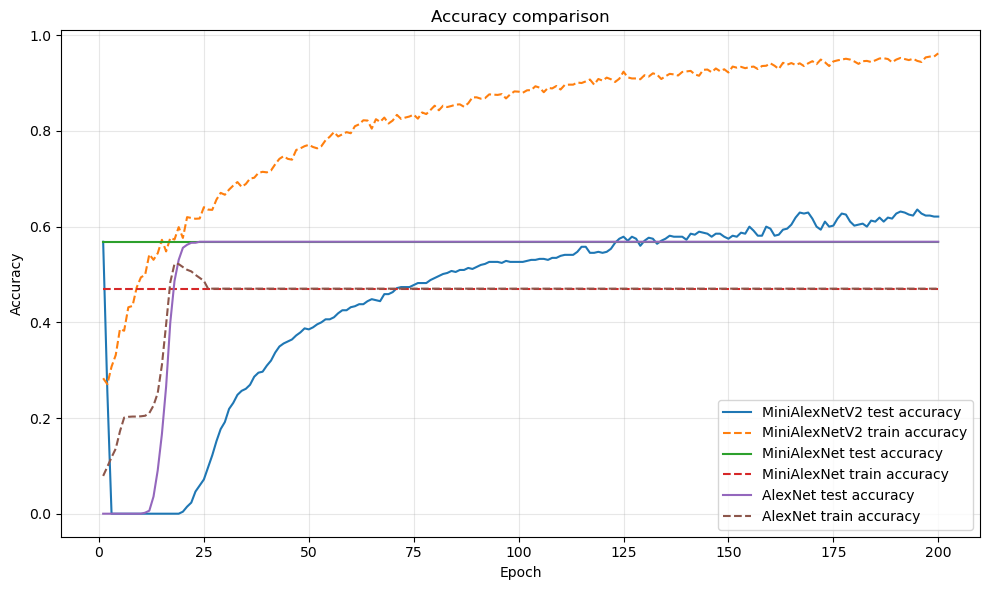

In [2]:
Function.plot_multiple_accuracy(csv_files, labels, graphsDir / "Confronto_Acc.png")

<h1>Loss Graphs</h1>

<h2>Confronto Loss tra le 3 reti</h2>
In questa parte prenderemo e mostreremo in un primo grafico il confronto tra le 3 reti neurali AlexNet, MiniAlexNet e MiniAlexNetV2

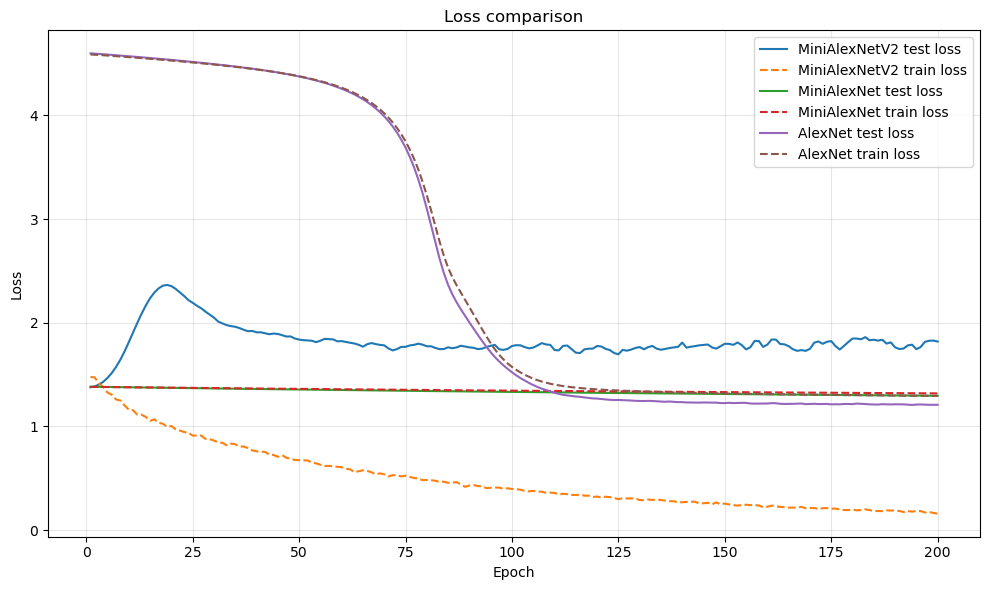

In [3]:
Function.plot_multiple_losses(csv_files, labels, graphsDir / "Confronto_Loss.png")

<h1>Stampa Tutti i grafici</h1>

In [4]:
#resize normale
tran = transforms.Compose([StreetSign.Rescale(32),StreetSign.RandomCrop(32),StreetSign.ToTensor()])

In [5]:
datatrain = StreetSign.StreetSignDataset(csvDir / 'classes.csv',imageDir,tran)
datatest = StreetSign.StreetSignTest( Test / 'prova.txt',Test,tran)

In [6]:
datatrain_loader = DataLoader(datatrain, batch_size=1024, shuffle=True)
datatest_loader = DataLoader(datatest, batch_size=1024, shuffle=True)

In [7]:
epoche        = 200 
learning_rate = 0.001
momento       = 0.6

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.838
  Classe 1: 0.878
  Classe 2: 0.934

AUC macro (media): 0.883


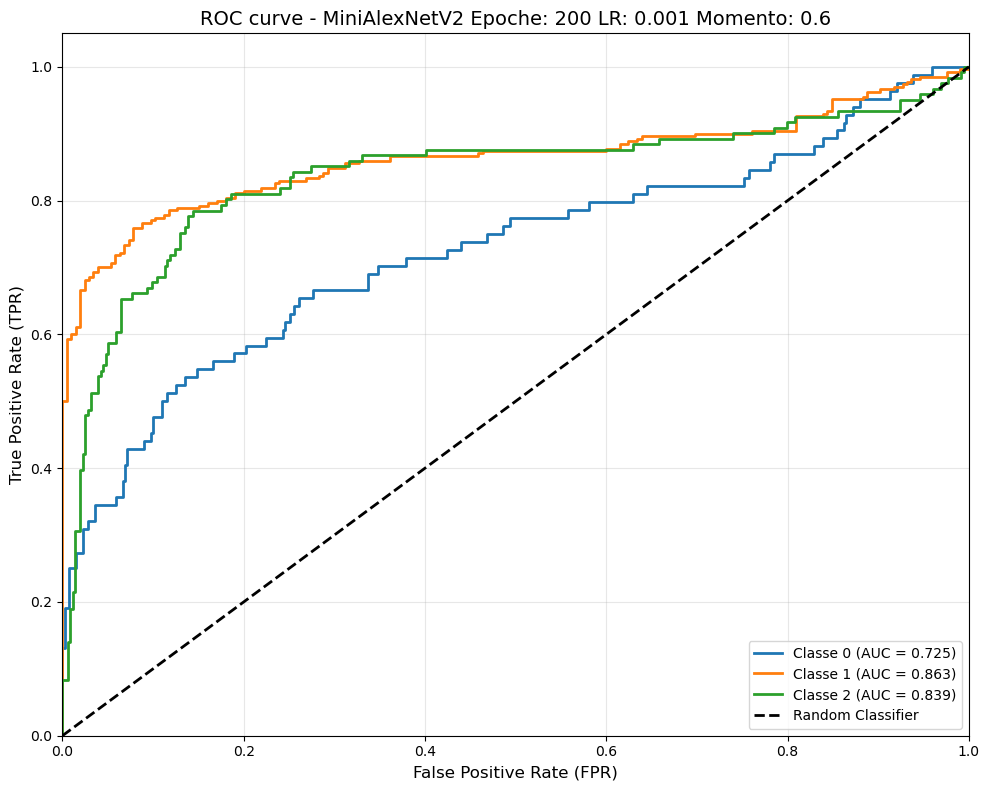

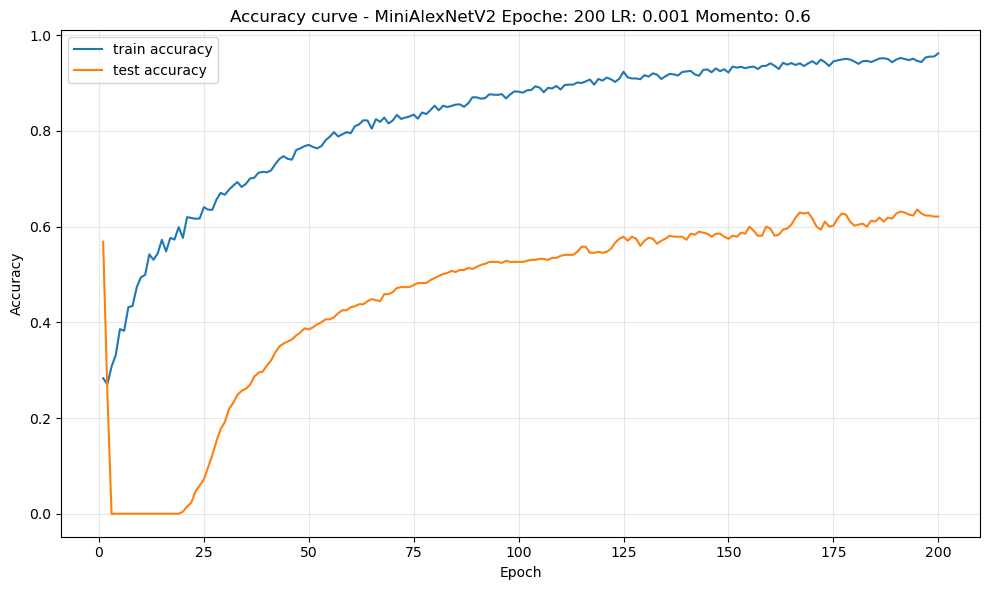

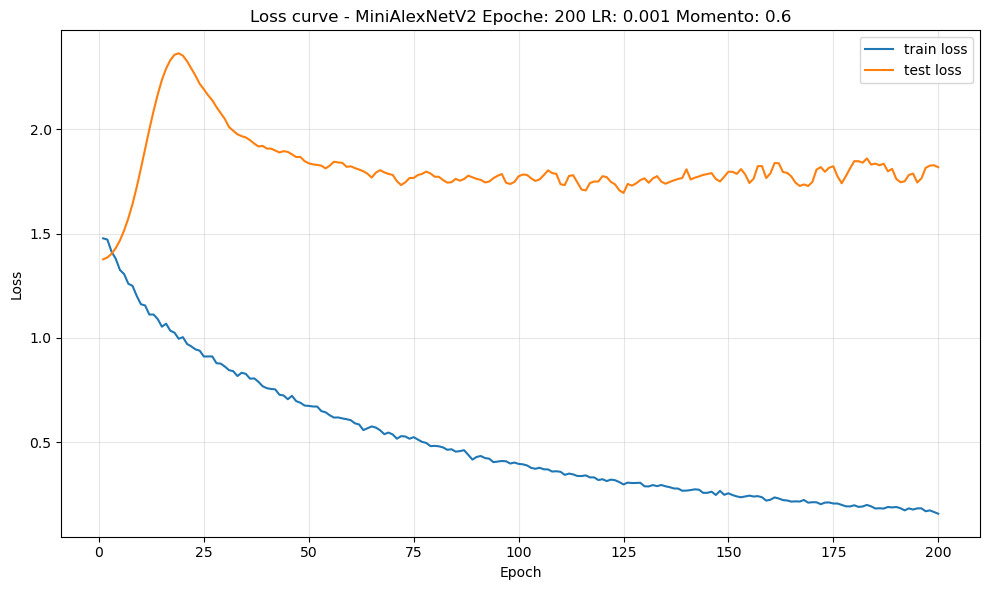

In [8]:

exp_name='MiniAlexNetV2'

file_csv     = historiesDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.csv'
titleAcc     = f'Accuracy curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
titleLoss    = f'Loss curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
titleROC     = f'ROC curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
outAcc_path  = graphsDir / f'{exp_name}_Acc_lr{learning_rate}_m{momento}_{epoche}.png'
outLoss_path = graphsDir / f'{exp_name}_Loss_lr{learning_rate}_m{momento}_{epoche}.png'
outROC_path  = graphsDir / f'{exp_name}_ROC_lr{learning_rate}_m{momento}_{epoche}.png'
model_path   = modelliDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.pth'

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Network.MiniAlexNetV2()
model.load_state_dict(torch.load(model_path))
model.to(device)
model.eval()

probabilities, labels = Function.test_classifier(model, datatest_loader)

Function.plot_roc_curve(labels, probabilities, titleROC, outROC_path)
Function.plot_accuracy_from_csv(file_csv, titleAcc, outAcc_path)
Function.plot_loss_from_csv(file_csv, titleLoss, outLoss_path)

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.476
  Classe 1: 0.452
  Classe 2: 0.467

AUC macro (media): 0.465


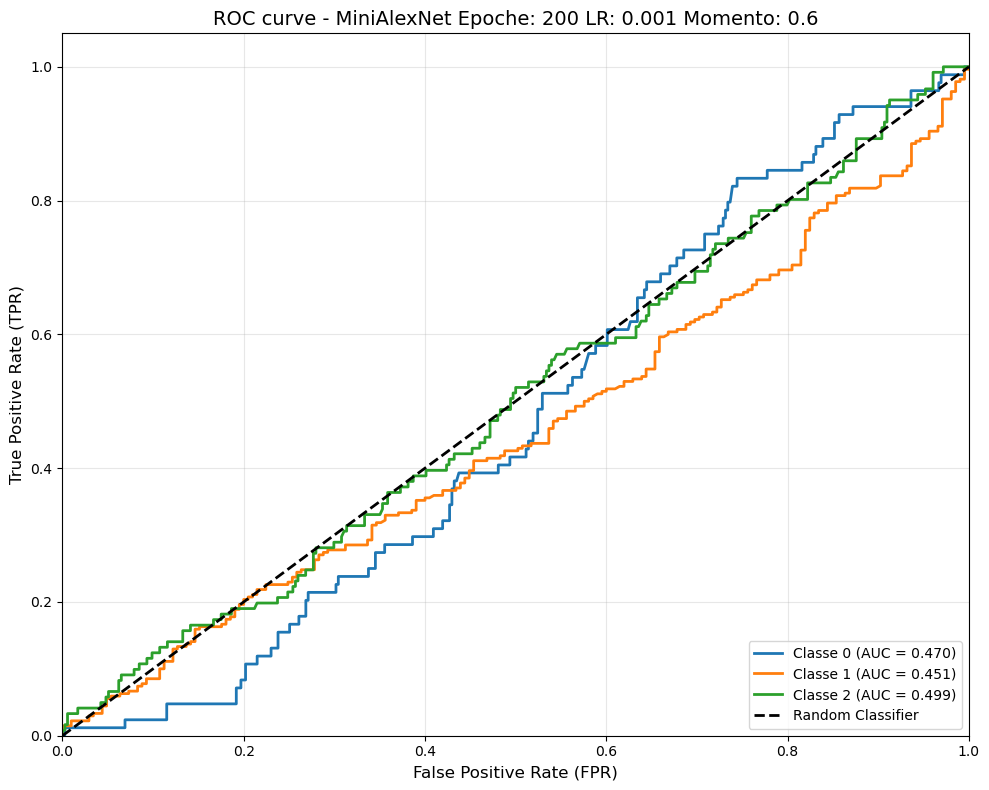

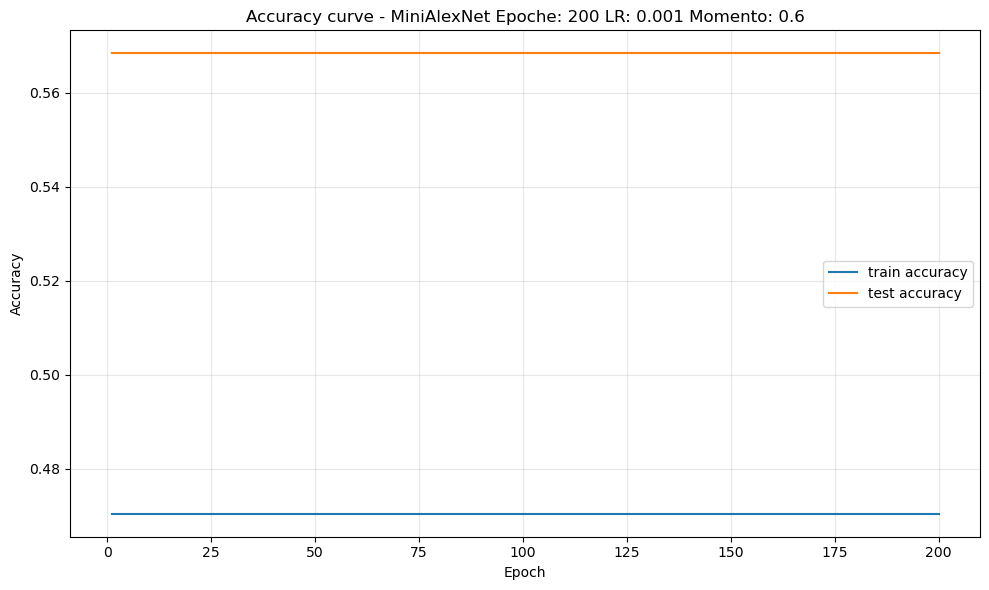

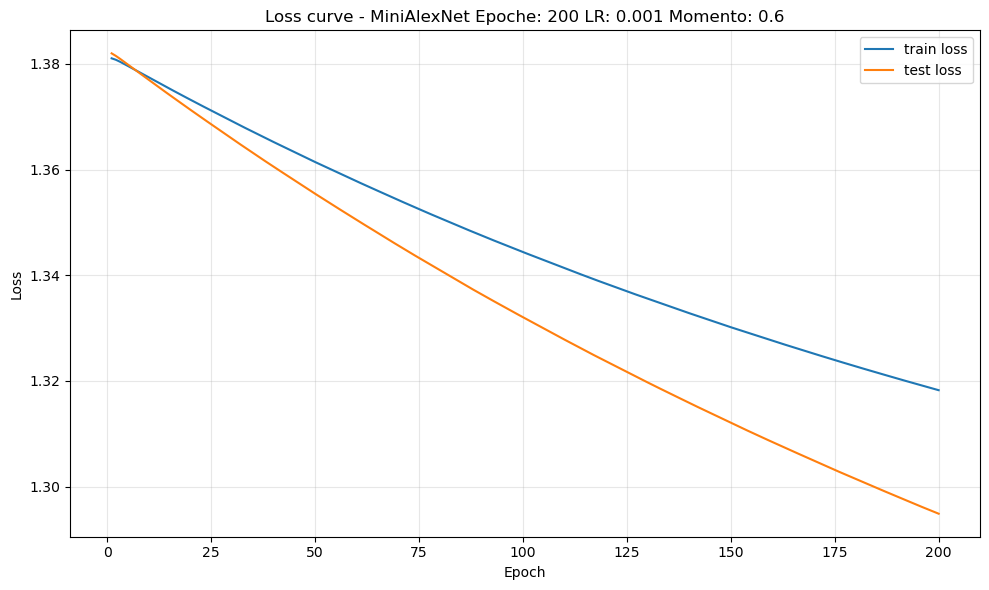

In [9]:
exp_name='MiniAlexNet'

file_csv     = historiesDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.csv'
titleAcc     = f'Accuracy curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
titleLoss    = f'Loss curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
titleROC     = f'ROC curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
outAcc_path  = graphsDir / f'{exp_name}_Acc_lr{learning_rate}_m{momento}_{epoche}.png'
outLoss_path = graphsDir / f'{exp_name}_Loss_lr{learning_rate}_m{momento}_{epoche}.png'
outROC_path  = graphsDir / f'{exp_name}_ROC_lr{learning_rate}_m{momento}_{epoche}.png'
model_path   = modelliDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.pth'

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Network.MiniAlexNet()
model.load_state_dict(torch.load(model_path))
model.to(device)
model.eval()

probabilities, labels = Function.test_classifier(model, datatest_loader)

Function.plot_roc_curve(labels, probabilities, titleROC, outROC_path)
Function.plot_accuracy_from_csv(file_csv, titleAcc, outAcc_path)
Function.plot_loss_from_csv(file_csv, titleLoss, outLoss_path)

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.448
  Classe 1: 0.464
  Classe 2: 0.520

AUC macro (media): 0.477


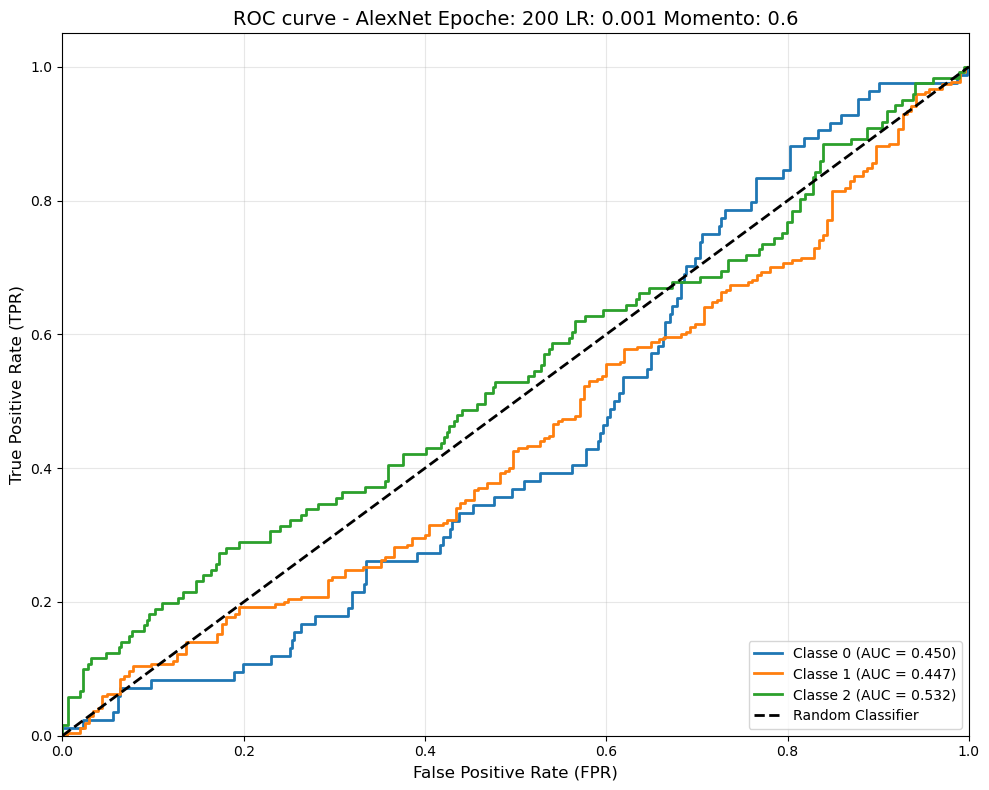

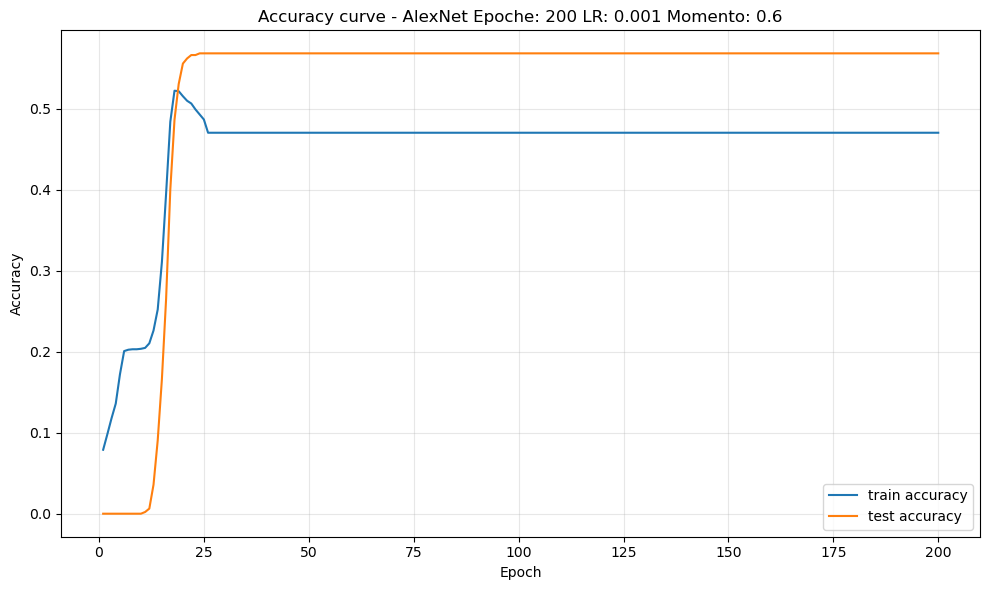

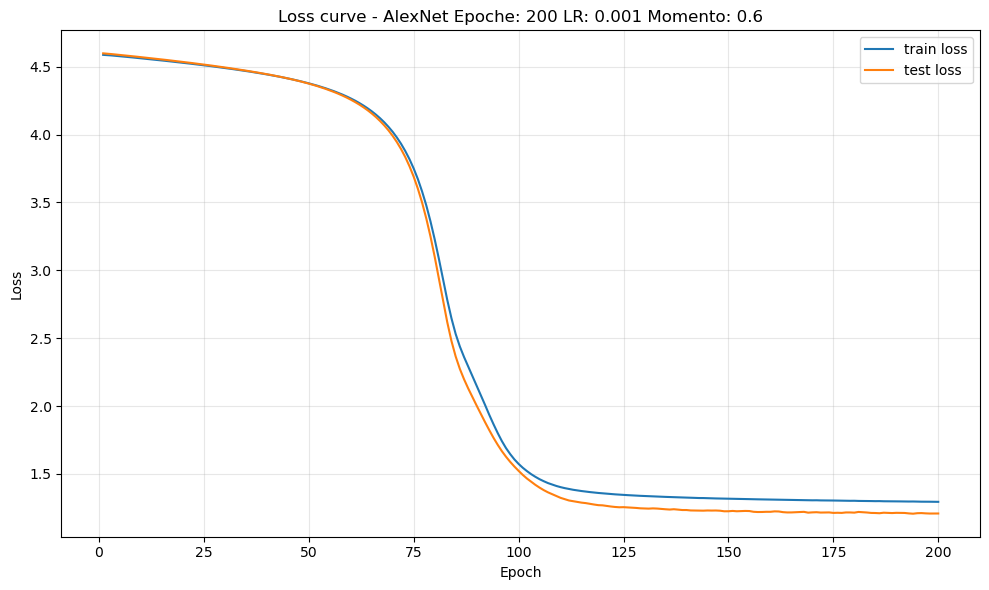

In [10]:
exp_name='AlexNet'

file_csv     = historiesDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.csv'
titleAcc     = f'Accuracy curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
titleLoss    = f'Loss curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
titleROC     = f'ROC curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
outAcc_path  = graphsDir / f'{exp_name}_Acc_lr{learning_rate}_m{momento}_{epoche}.png'
outLoss_path = graphsDir / f'{exp_name}_Loss_lr{learning_rate}_m{momento}_{epoche}.png'
outROC_path  = graphsDir / f'{exp_name}_ROC_lr{learning_rate}_m{momento}_{epoche}.png'
model_path   = modelliDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.pth'

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Network.LeNetColor()
model.load_state_dict(torch.load(model_path))
model.to(device)
model.eval()

probabilities, labels = Function.test_classifier(model, datatest_loader)

Function.plot_roc_curve(labels, probabilities, titleROC, outROC_path)
Function.plot_accuracy_from_csv(file_csv, titleAcc, outAcc_path)
Function.plot_loss_from_csv(file_csv, titleLoss, outLoss_path)

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.703
  Classe 1: 0.669
  Classe 2: 0.742

AUC macro (media): 0.705


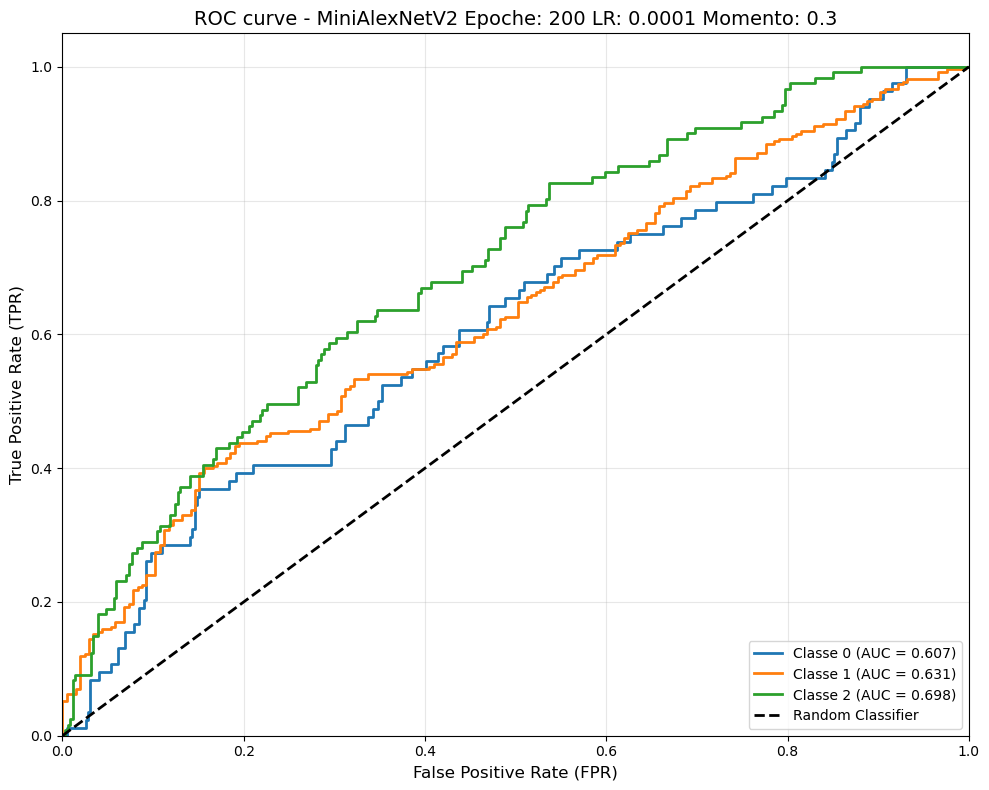

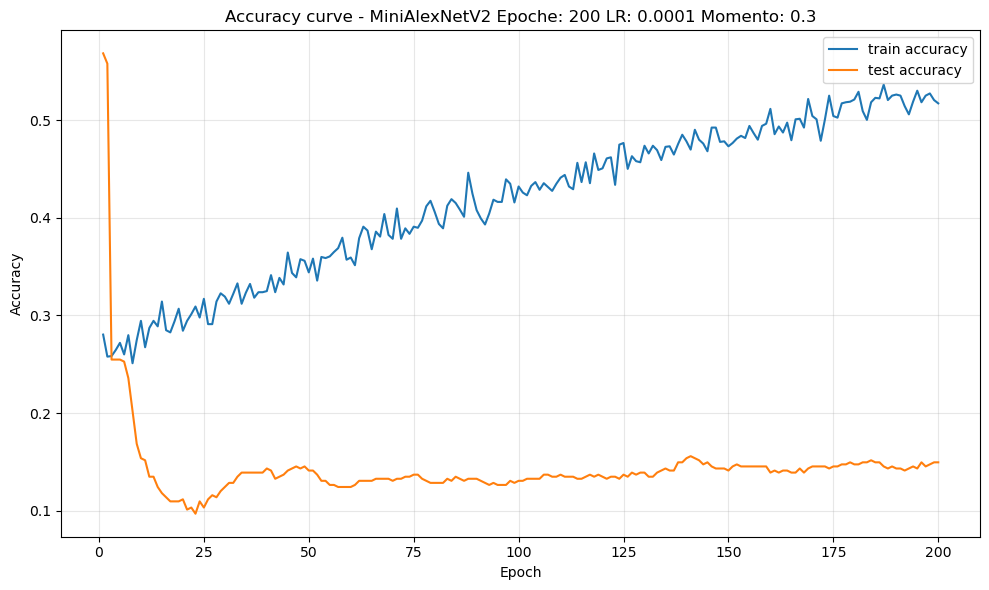

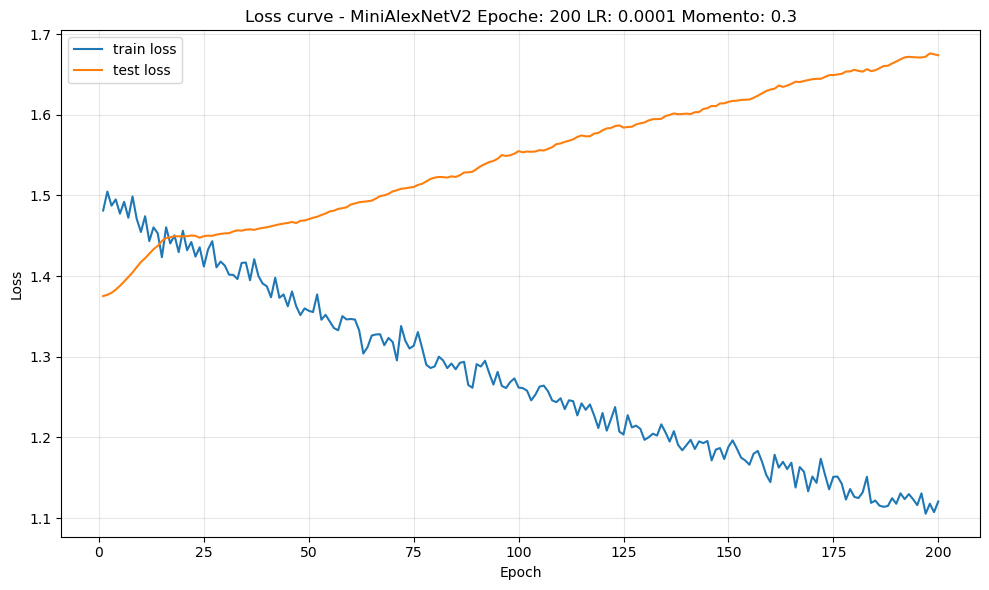

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.734
  Classe 1: 0.638
  Classe 2: 0.777

AUC macro (media): 0.716


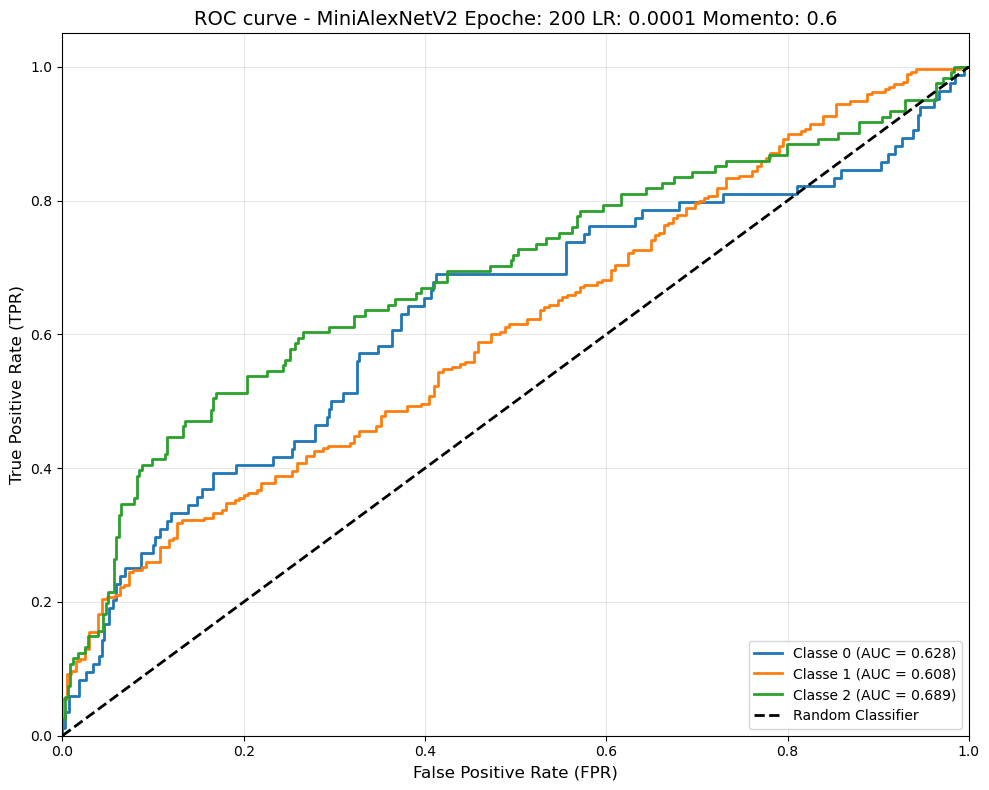

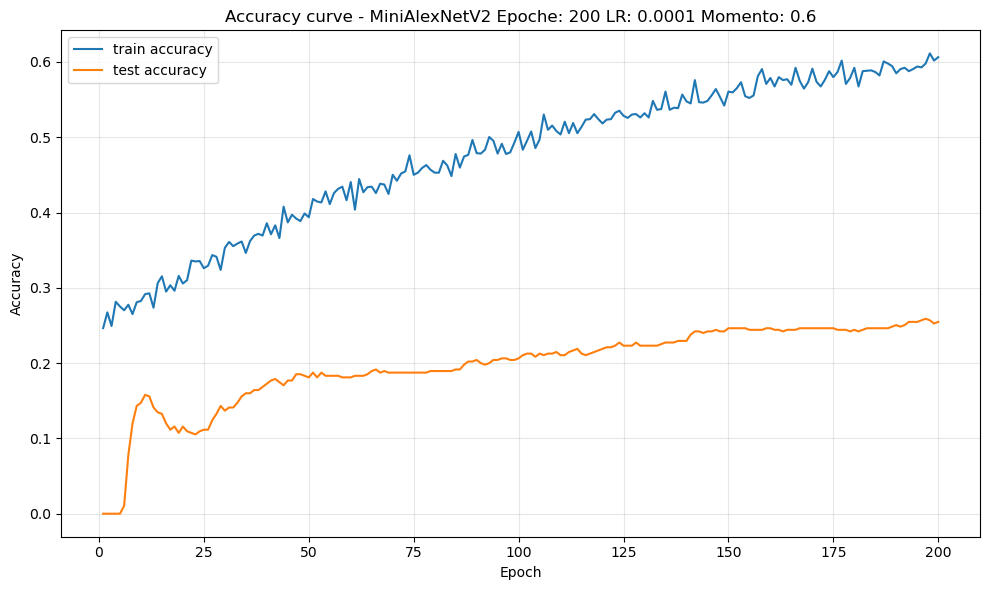

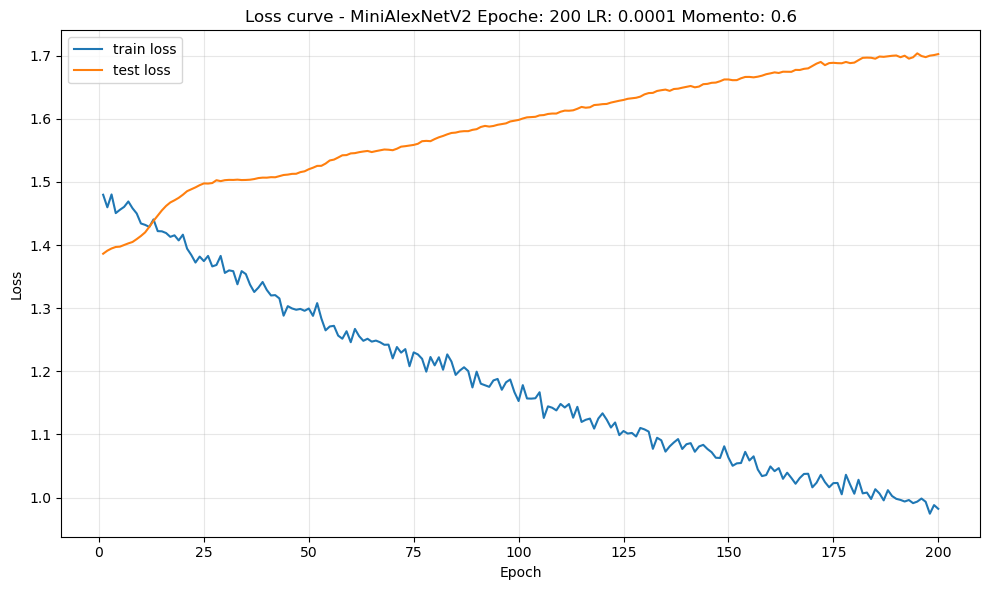

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.784
  Classe 1: 0.800
  Classe 2: 0.869

AUC macro (media): 0.818


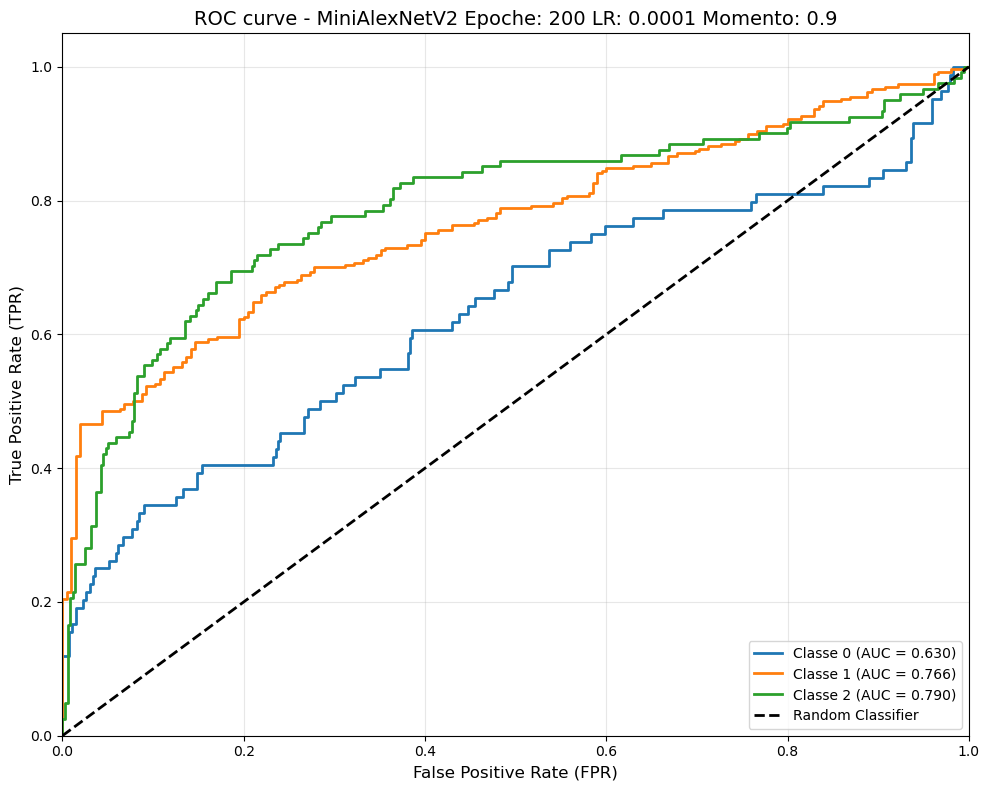

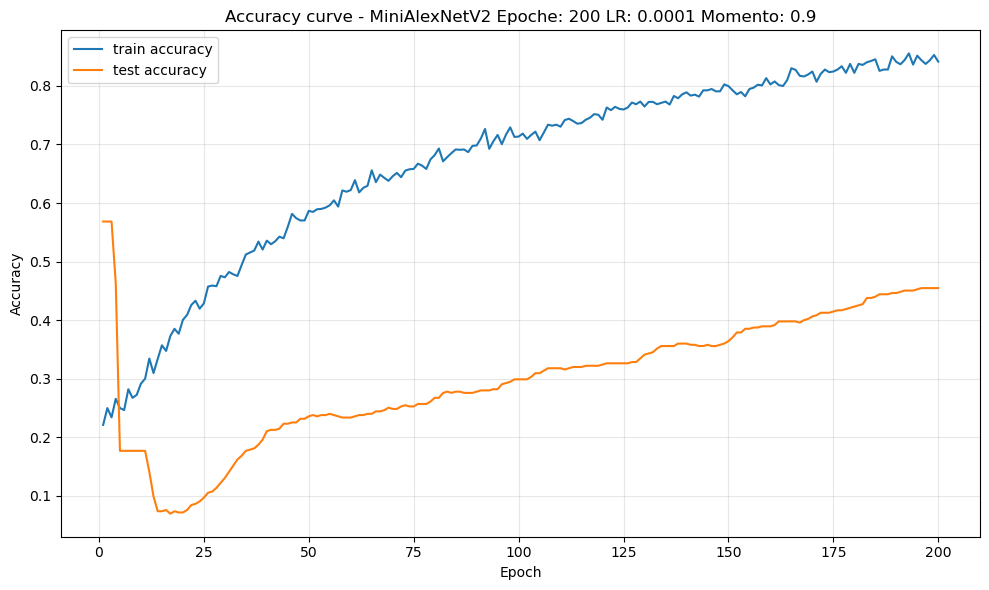

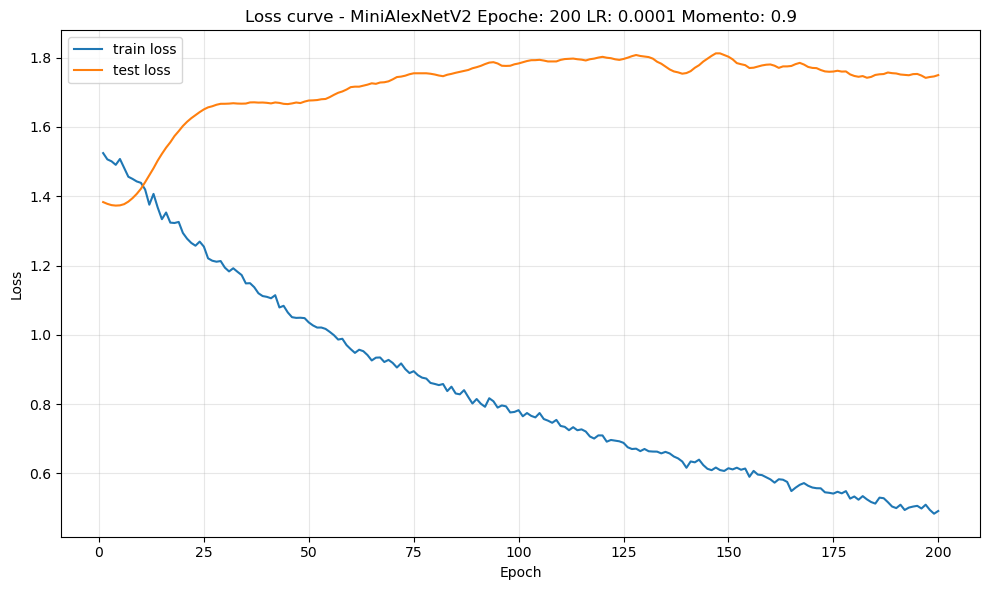

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.811
  Classe 1: 0.840
  Classe 2: 0.897

AUC macro (media): 0.849


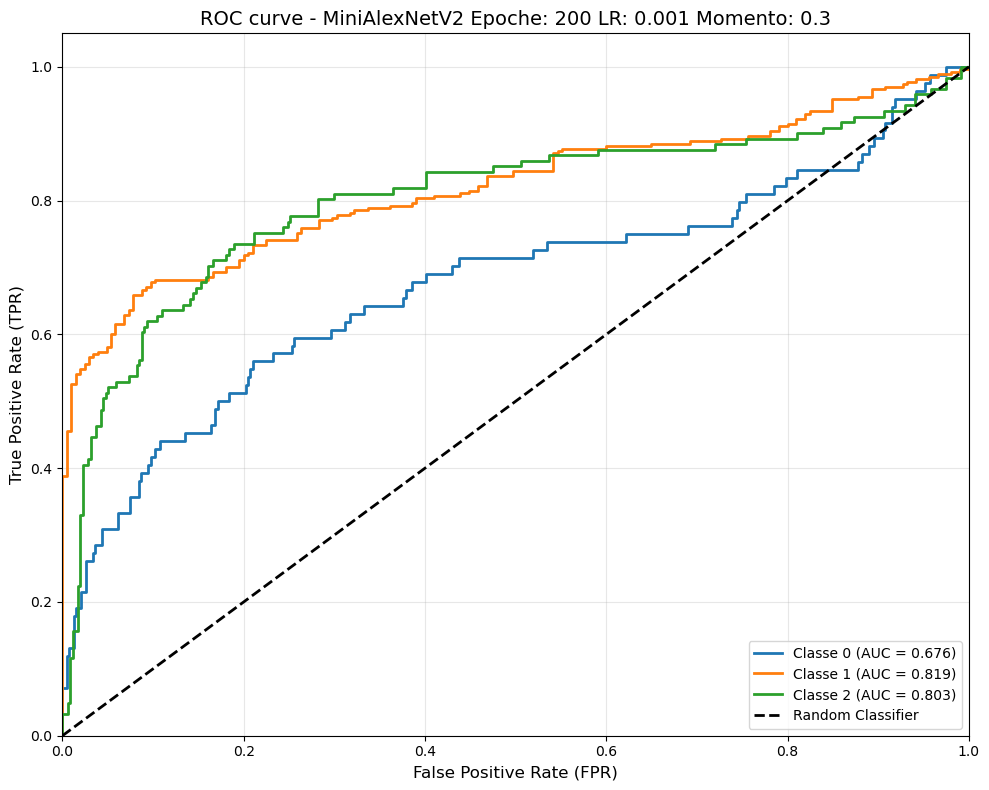

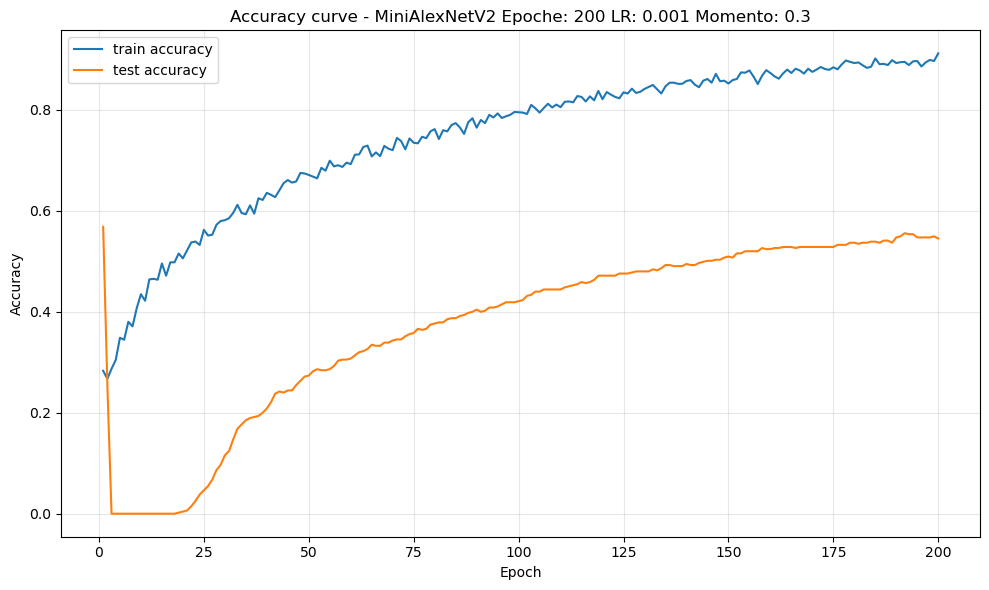

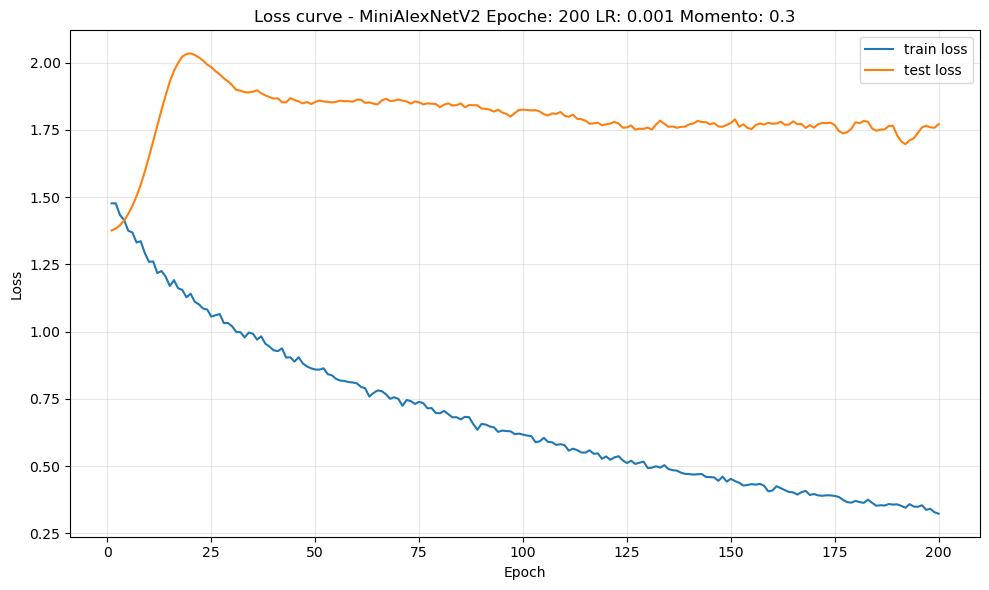

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.838
  Classe 1: 0.878
  Classe 2: 0.934

AUC macro (media): 0.883


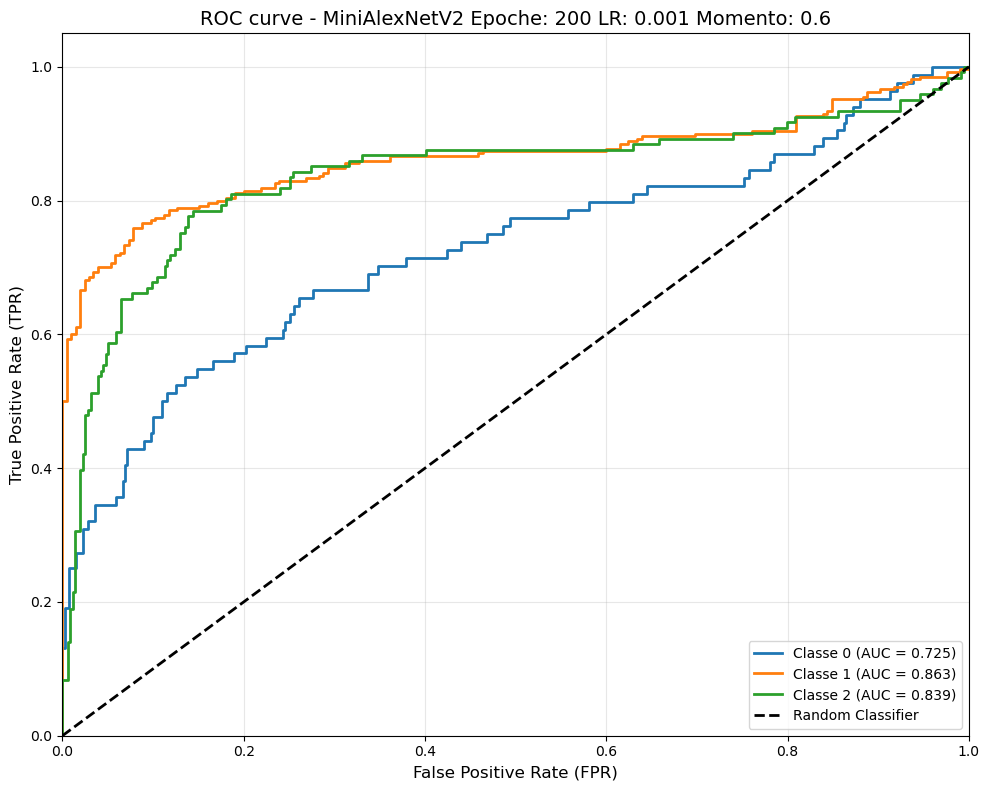

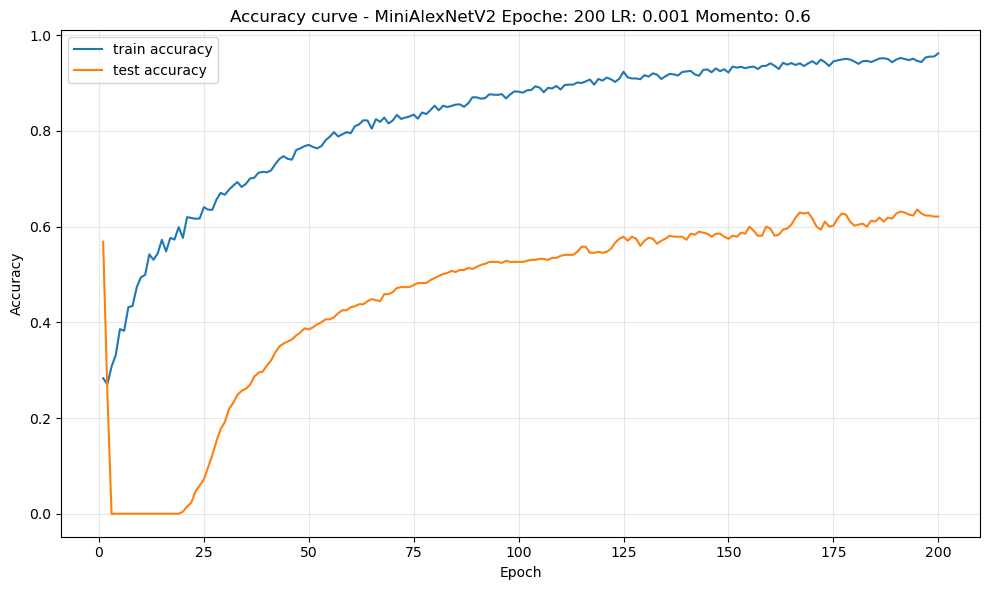

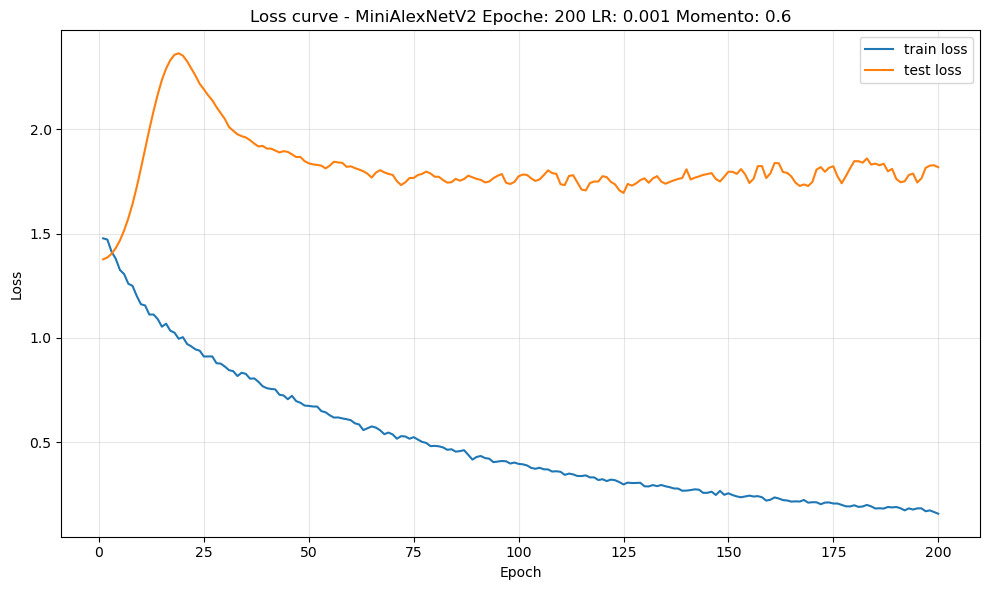

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.915
  Classe 1: 0.924
  Classe 2: 0.977

AUC macro (media): 0.939


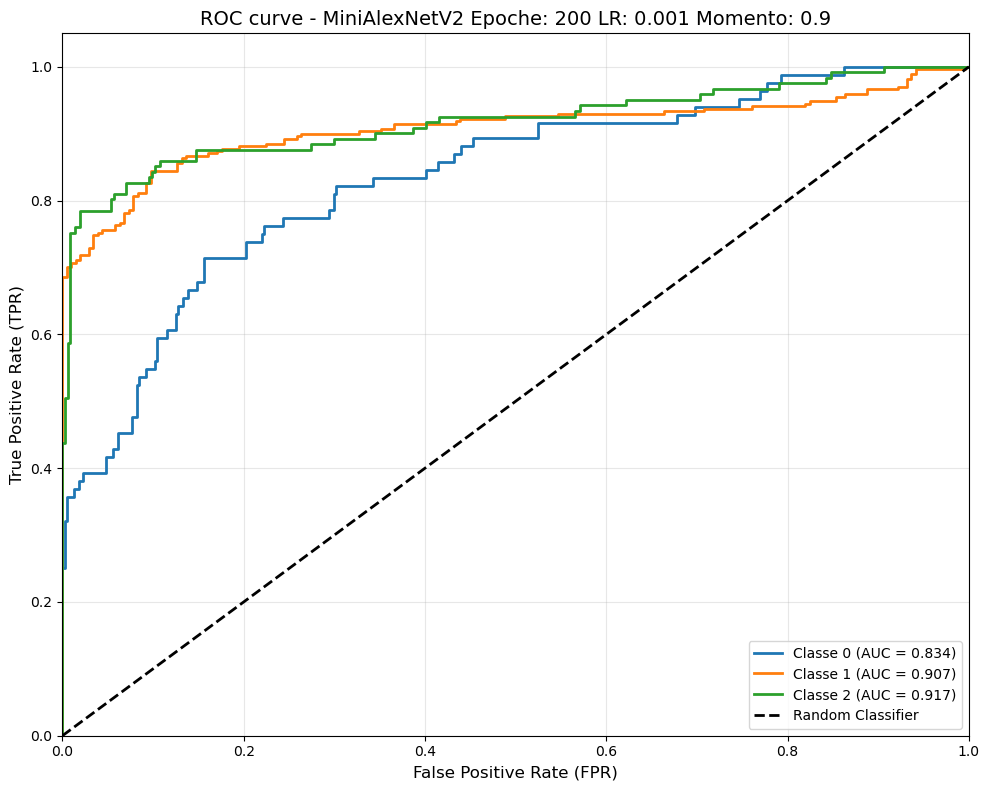

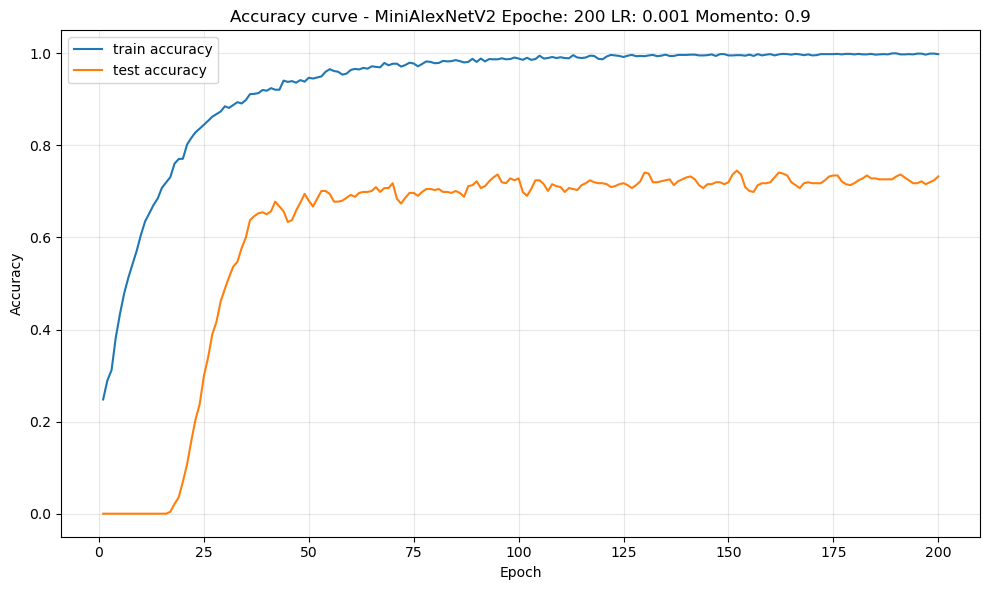

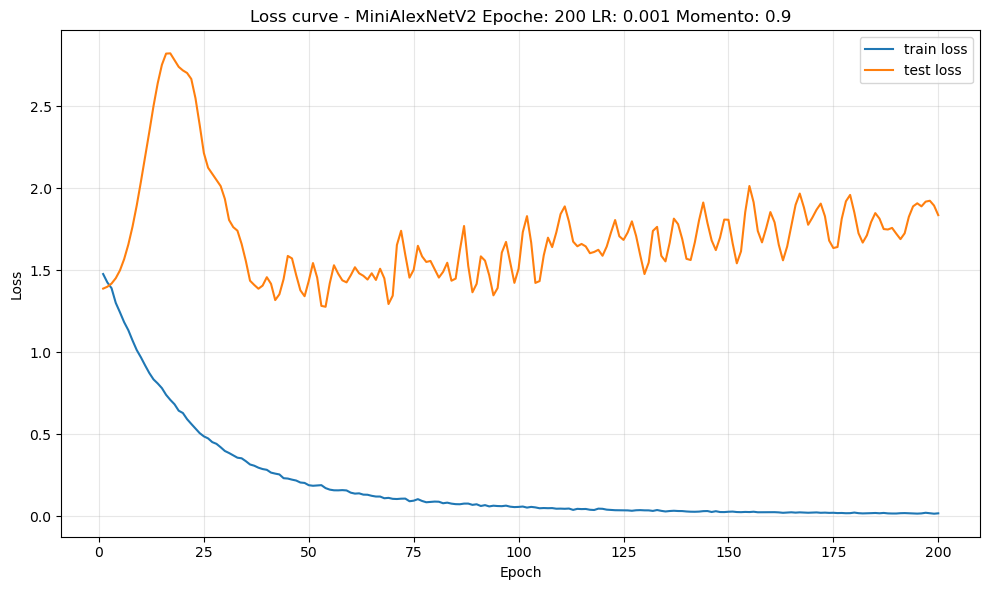

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.863
  Classe 1: 0.898
  Classe 2: 0.957

AUC macro (media): 0.906


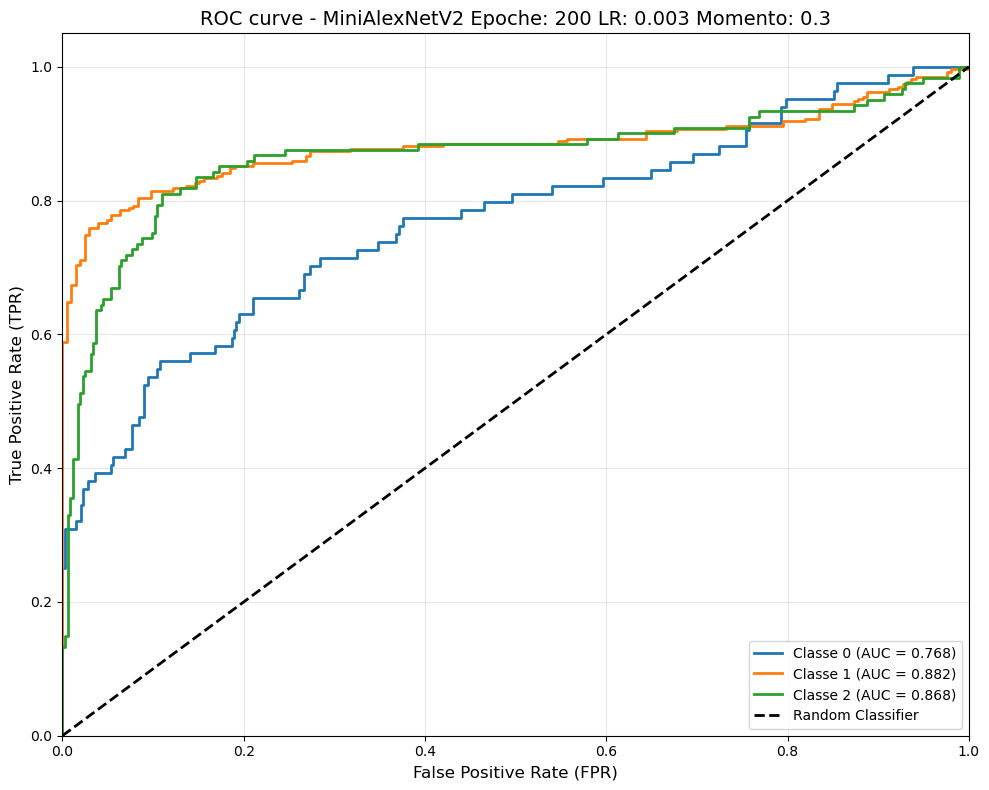

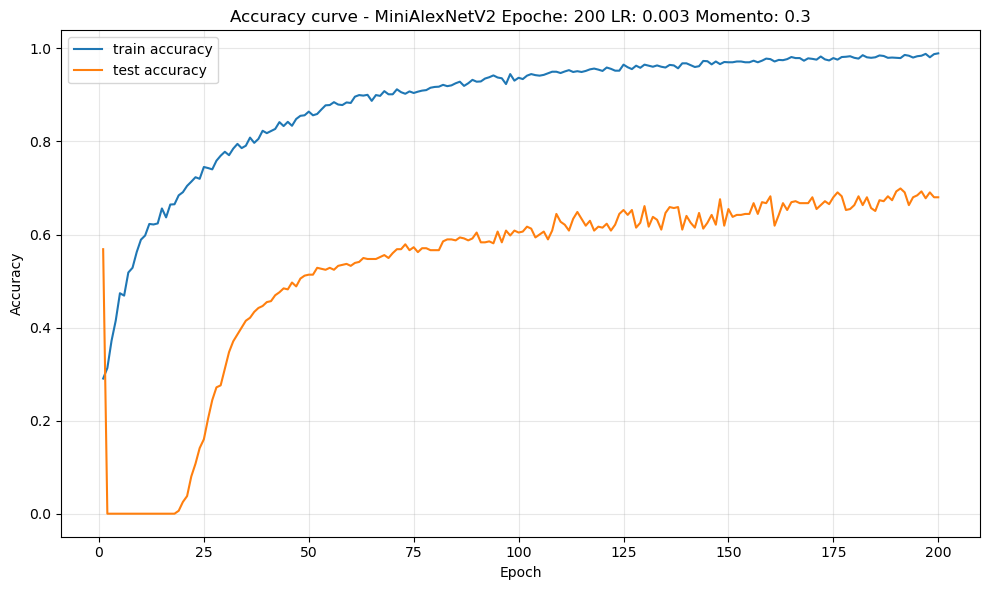

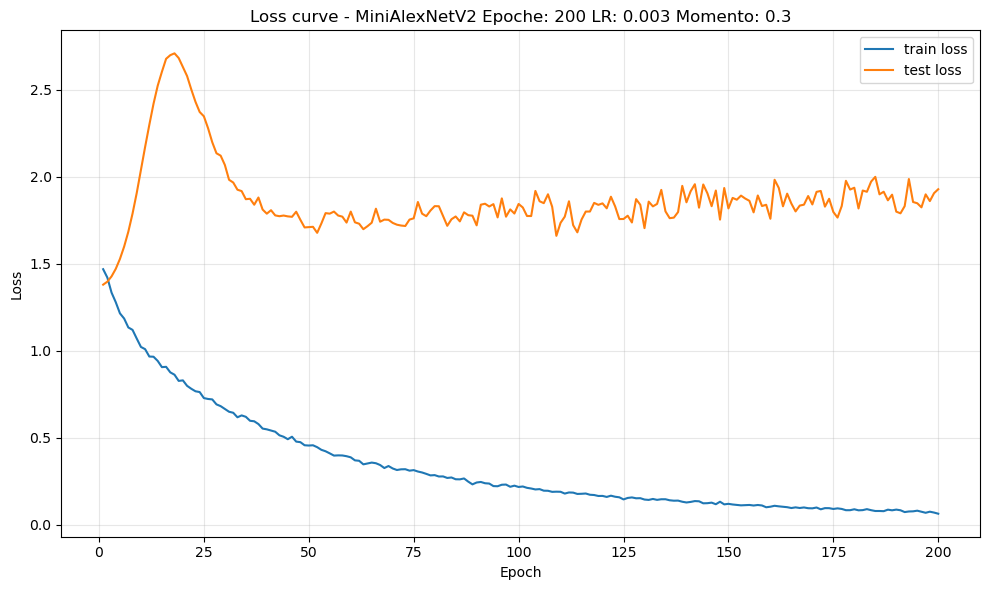

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.911
  Classe 1: 0.922
  Classe 2: 0.973

AUC macro (media): 0.935


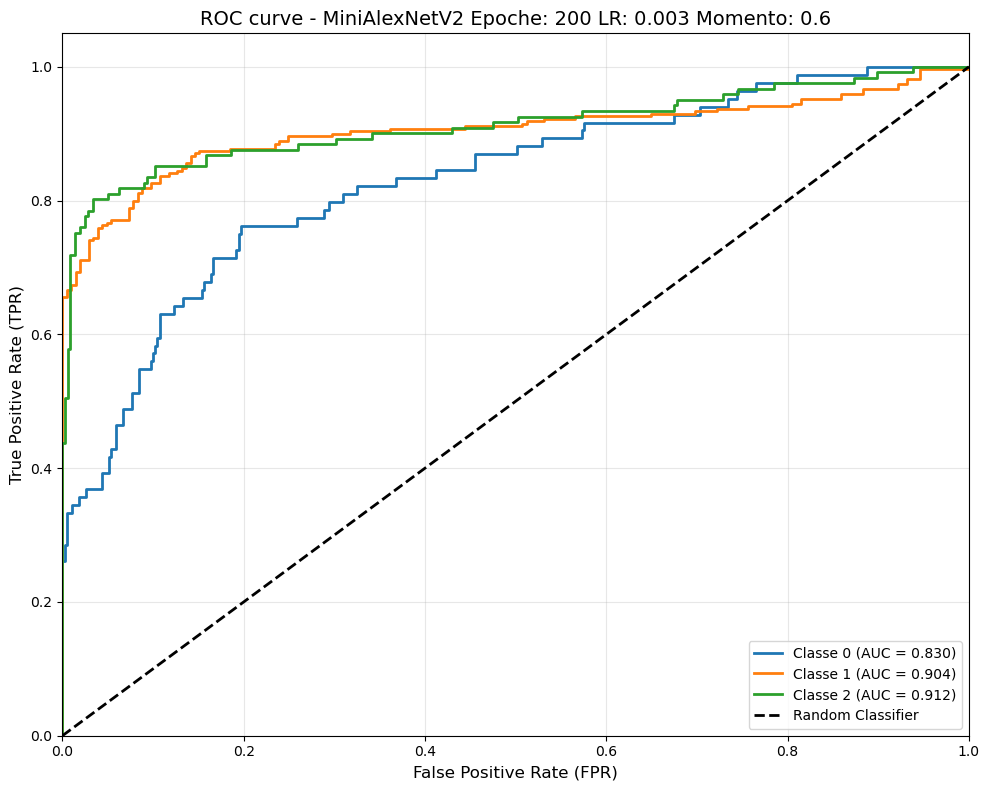

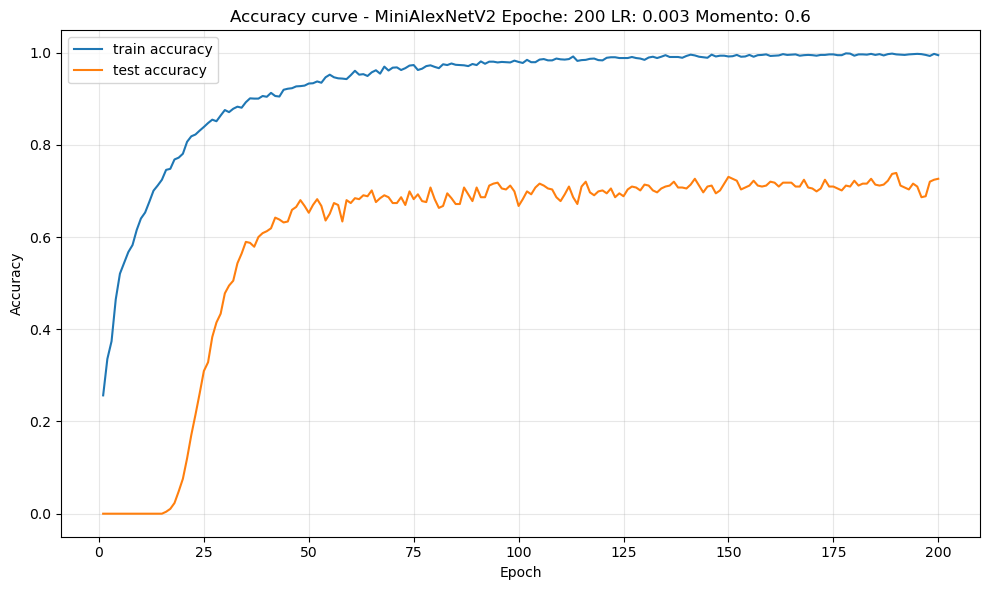

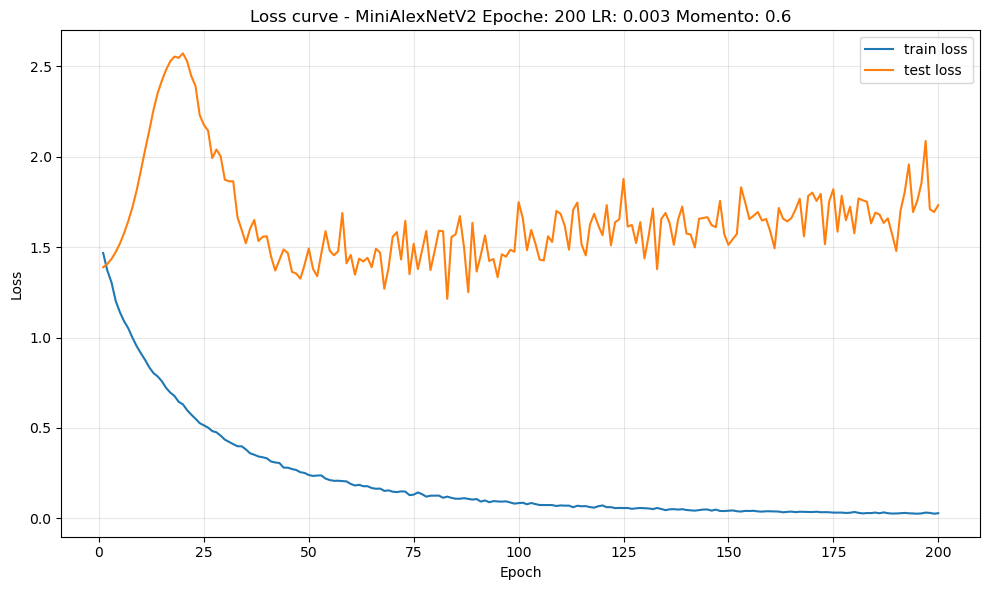

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.894
  Classe 1: 0.923
  Classe 2: 0.979

AUC macro (media): 0.932


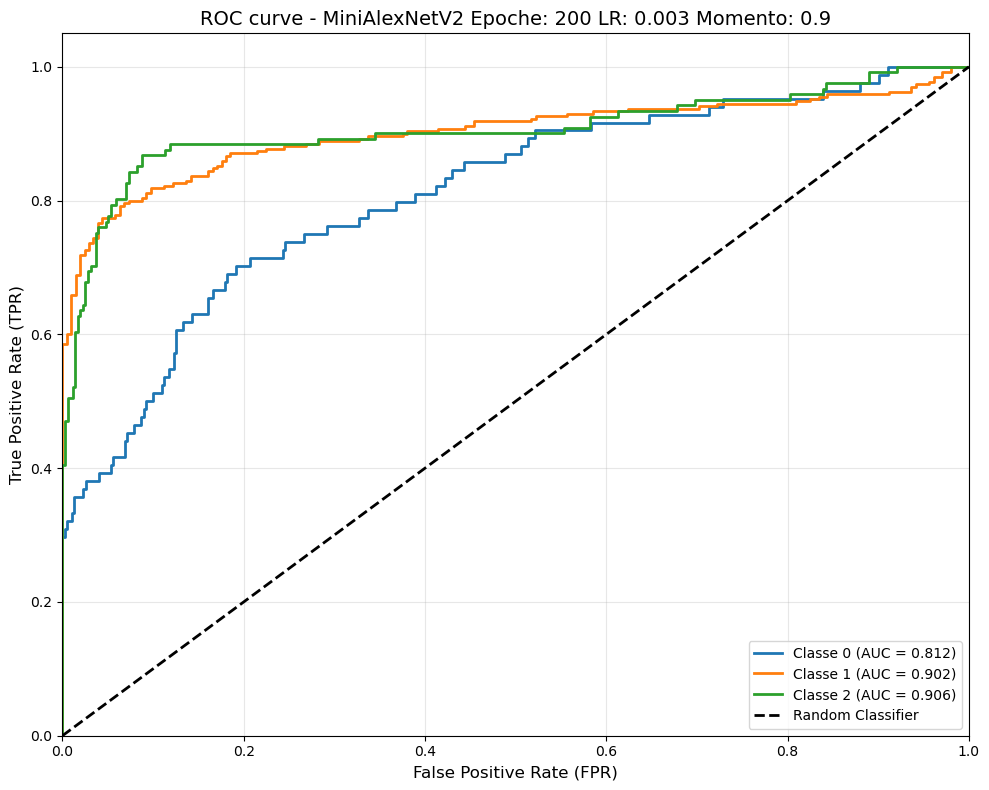

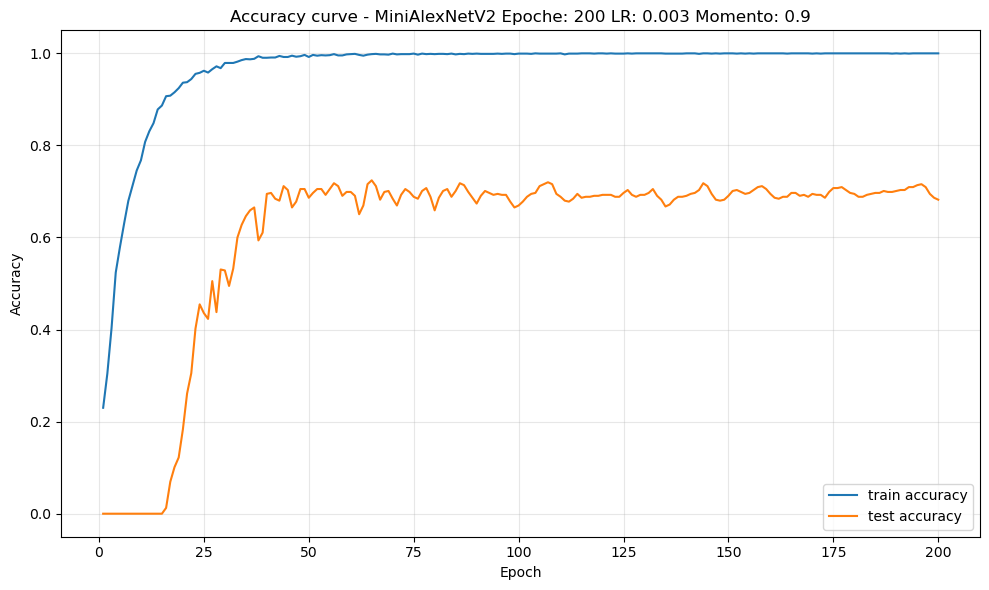

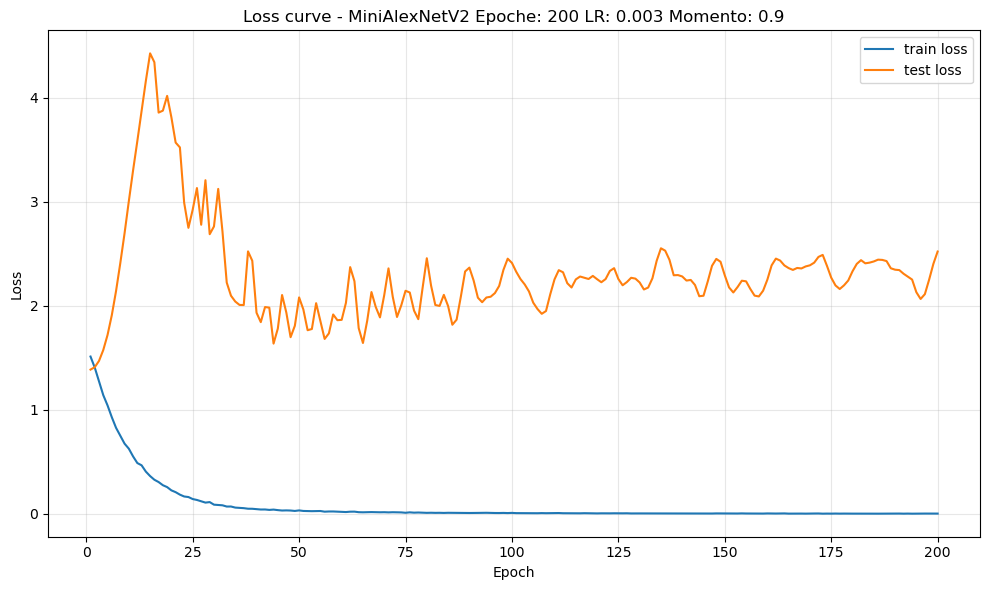

In [11]:
exp_name='MiniAlexNetV2'

configs = [
    (0.0001, 0.3),
    (0.0001, 0.6),
    (0.0001, 0.9),
    (0.001, 0.3),
    (0.001, 0.6),
    (0.001, 0.9),
    (0.003, 0.3),
    (0.003, 0.6),
    (0.003, 0.9),
]

for lr, m in configs:
    learning_rate = lr
    momento = m

    file_csv     = historiesDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.csv'
    titleAcc     = f'Accuracy curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
    titleLoss    = f'Loss curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
    titleROC     = f'ROC curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
    outAcc_path  = graphsDir / f'{exp_name}_Acc_lr{learning_rate}_m{momento}_{epoche}.png'
    outLoss_path = graphsDir / f'{exp_name}_Loss_lr{learning_rate}_m{momento}_{epoche}.png'
    outROC_path  = graphsDir / f'{exp_name}_ROC_lr{learning_rate}_m{momento}_{epoche}.png'
    model_path   = modelliDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.pth'

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = Network.MiniAlexNetV2()
    model.load_state_dict(torch.load(model_path))
    model.to(device)
    model.eval()

    probabilities, labels = Function.test_classifier(model, datatest_loader)

    Function.plot_roc_curve(labels, probabilities, titleROC, outROC_path)
    Function.plot_accuracy_from_csv(file_csv, titleAcc, outAcc_path)
    Function.plot_loss_from_csv(file_csv, titleLoss, outLoss_path)

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.894
  Classe 1: 0.921
  Classe 2: 0.979

AUC macro (media): 0.931


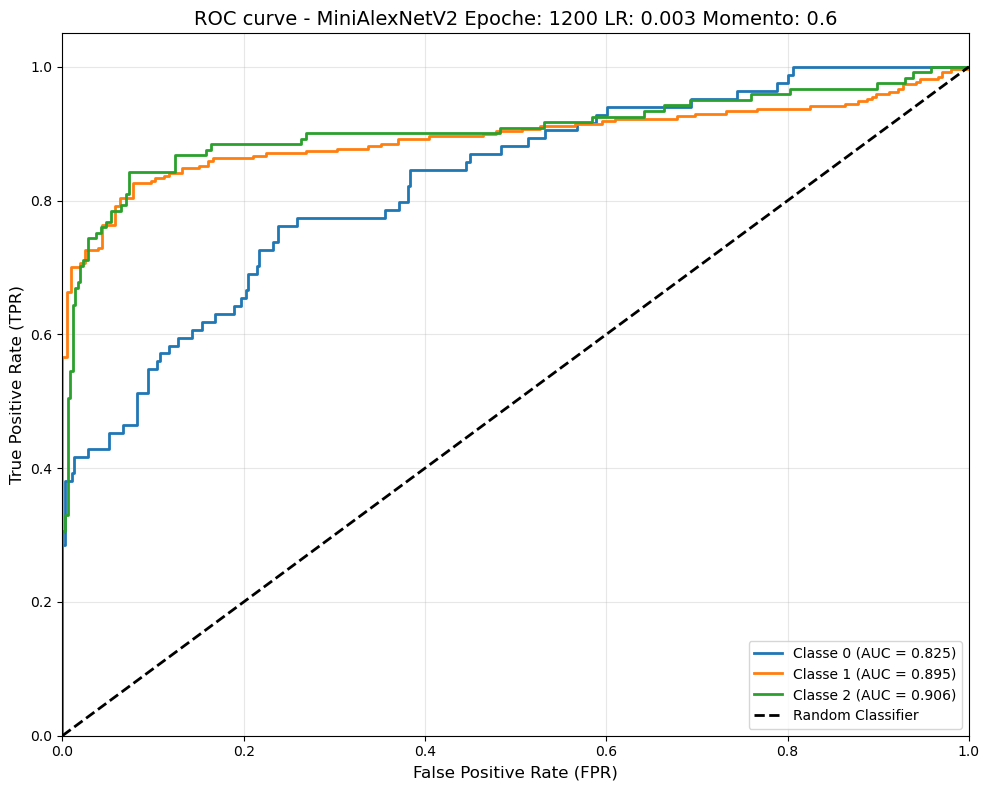

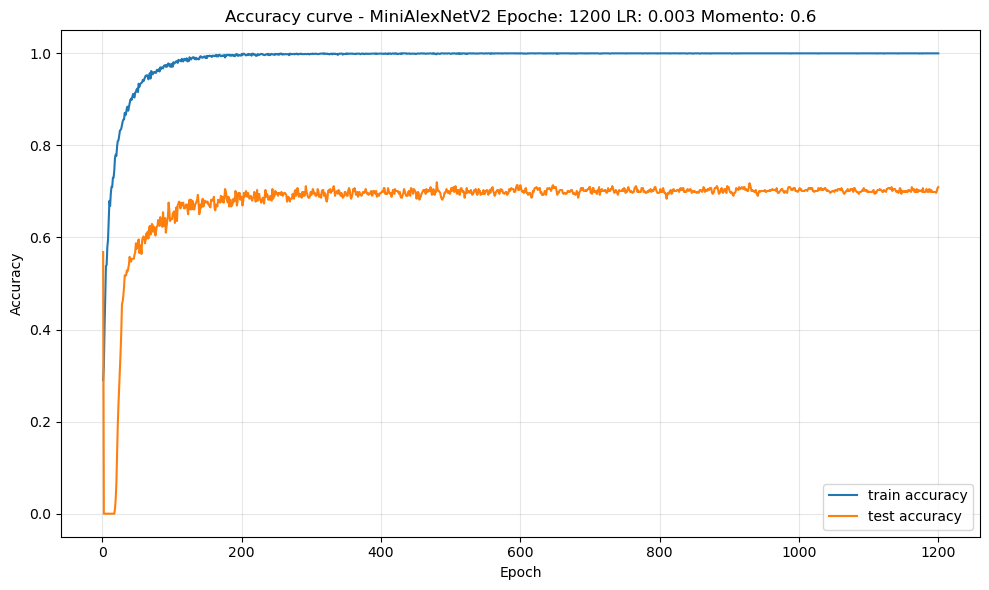

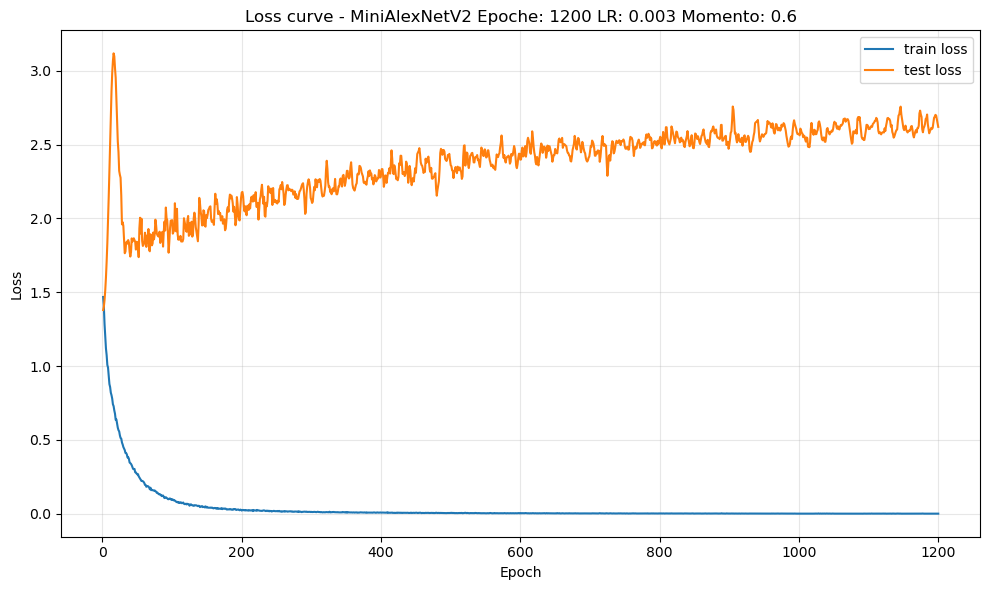

In [12]:
epoche        = 1200 
learning_rate = 0.003
momento       = 0.6
exp_name='MiniAlexNetV2'

file_csv     = historiesDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.csv'
titleAcc     = f'Accuracy curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
titleLoss    = f'Loss curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
titleROC     = f'ROC curve - {exp_name} Epoche: {epoche} LR: {learning_rate} Momento: {momento}'
outAcc_path  = graphsDir / f'{exp_name}_Acc_lr{learning_rate}_m{momento}_{epoche}.png'
outLoss_path = graphsDir / f'{exp_name}_Loss_lr{learning_rate}_m{momento}_{epoche}.png'
outROC_path  = graphsDir / f'{exp_name}_ROC_lr{learning_rate}_m{momento}_{epoche}.png'
model_path   = modelliDir / f'{exp_name}_lr{learning_rate}_m{momento}-{epoche}.pth'

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Network.MiniAlexNetV2()
model.load_state_dict(torch.load(model_path))
model.to(device)
model.eval()

probabilities, labels = Function.test_classifier(model, datatest_loader)

Function.plot_roc_curve(labels, probabilities, titleROC, outROC_path)
Function.plot_accuracy_from_csv(file_csv, titleAcc, outAcc_path)
Function.plot_loss_from_csv(file_csv, titleLoss, outLoss_path)